In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

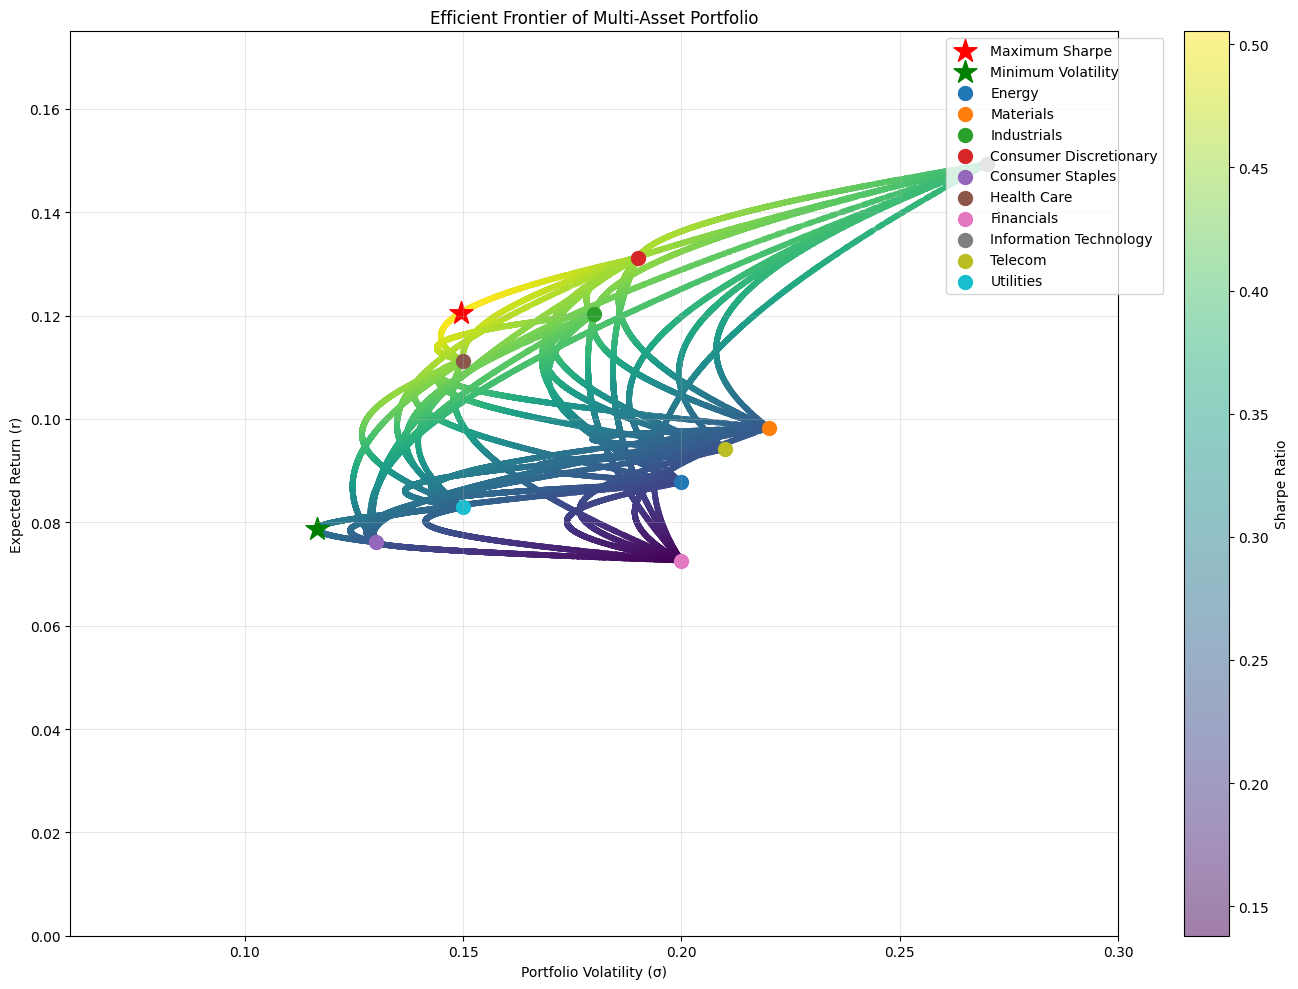

--------------------------------------------------
Maximum Sharpe Ratio Portfolio Allocation

Energy: 0.00%
Materials: 0.00%
Industrials: 0.00%
Consumer Discretionary: 46.57%
Consumer Staples: 0.00%
Health Care: 53.43%
Financials: 0.00%
Information Technology: 0.00%
Telecom: 0.00%
Utilities: 0.00%
Expected Return: 12.05%
Expected Volatility: 14.95%
Sharpe Ratio: 0.51

--------------------------------------------------
Minimum Volatility Portfolio Allocation

Energy: 0.00%
Materials: 0.00%
Industrials: 0.00%
Consumer Discretionary: 0.00%
Consumer Staples: 62.16%
Health Care: 0.00%
Financials: 0.00%
Information Technology: 0.00%
Telecom: 0.00%
Utilities: 37.84%
Expected Return: 7.87%
Expected Volatility: 11.66%
Sharpe Ratio: 0.29


In [3]:
class MultiAssetOptimisation:
    def __init__(self, returns, volatilities, correlation_matrix, asset_names, num_portfolios=100000, risk_free_rate=0.045, weighting_style='normalised'):
        self.returns = np.array(returns)
        self.volatilities = np.array(volatilities)
        self.asset_names = asset_names
        self.correlation_matrix = np.array(correlation_matrix)
        self.num_portfolios = num_portfolios
        self.risk_free_rate = risk_free_rate
        self.weighting_style = weighting_style
        self.cov_matrix = self._get_covariance_matrix()
        self.ALPHA = 0.3

    def _get_covariance_matrix(self):
        return np.outer(self.volatilities, self.volatilities) * self.correlation_matrix

    def _get_weights(self):
        n = len(self.returns)

        if self.weighting_style == 'normalised':
            weights = np.random.random((self.num_portfolios, n))
            weights /= weights.sum(axis=1)[:, None]

        elif self.weighting_style == 'dirichlet':
            # 0.3 here is 'alpha' = concentration coefficient
            # Where alpha controls:
            # alpha < 1: more sparse allocations (closer to pure assets),
            # alpha = 1: uniform Dirichlet,
            # alpha > 1: more evenly spread allocations.
            weights = np.random.dirichlet(self.ALPHA * np.ones(n), size=self.num_portfolios)

        elif self.weighting_style == 'constrain-assets':
            weights = []
            for _ in range(self.num_portfolios):
                w = np.zeros(n)
                i, j = np.random.choice(n, size=2, replace=False)
                vals = np.random.random(2)
                vals /= vals.sum()
                w[i], w[j] = vals
                weights.append(w)
            weights = np.array(weights)

        else:
            raise ValueError("Invalid weighting_style. Choose 'normalised', 'dirichlet', or 'constrain-assets'.")

        return weights

    def plot_efficient_frontier(self):
        weights = self._get_weights()

        portfolio_returns = weights @ self.returns
        portfolio_vols = np.array([
            np.sqrt(w.T @ self.cov_matrix @ w) for w in weights
        ])
        sharpe_ratios = (portfolio_returns - self.risk_free_rate) / portfolio_vols

        # Optimal portfolios
        max_sharpe_idx = np.argmax(sharpe_ratios)
        min_vol_idx = np.argmin(portfolio_vols)

        # Plot
        plt.figure(figsize=(14, 10))
        scatter = plt.scatter(portfolio_vols, portfolio_returns, c=sharpe_ratios, cmap='viridis', alpha=0.5, s=10)
        plt.colorbar(scatter).set_label('Sharpe Ratio')

        # Optimal points
        plt.scatter(portfolio_vols[max_sharpe_idx], portfolio_returns[max_sharpe_idx], c='red', marker='*', s=300, label='Maximum Sharpe')
        plt.scatter(portfolio_vols[min_vol_idx], portfolio_returns[min_vol_idx], c='green', marker='*', s=300, label='Minimum Volatility')

        # Plot individual assets
        for i, name in enumerate(self.asset_names):
            plt.scatter(self.volatilities[i], self.returns[i], marker='o', s=100, label=name)

        plt.title('Efficient Frontier of Multi-Asset Portfolio')
        plt.xlabel('Portfolio Volatility (σ)')
        plt.ylabel('Expected Return (r)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.xlim([0.06, 0.3])
        plt.ylim([0, 0.175])
        plt.show()

        # Print optimal portfolios
        print("-" * 50)
        print("Maximum Sharpe Ratio Portfolio Allocation\n")
        for i, name in enumerate(self.asset_names):
            print(f"{name}: {weights[max_sharpe_idx, i]:.2%}")
        print(f"Expected Return: {portfolio_returns[max_sharpe_idx]:.2%}")
        print(f"Expected Volatility: {portfolio_vols[max_sharpe_idx]:.2%}")
        print(f"Sharpe Ratio: {sharpe_ratios[max_sharpe_idx]:.2f}\n")

        print("-" * 50)
        print("Minimum Volatility Portfolio Allocation\n")
        for i, name in enumerate(self.asset_names):
            print(f"{name}: {weights[min_vol_idx, i]:.2%}")
        print(f"Expected Return: {portfolio_returns[min_vol_idx]:.2%}")
        print(f"Expected Volatility: {portfolio_vols[min_vol_idx]:.2%}")
        print(f"Sharpe Ratio: {sharpe_ratios[min_vol_idx]:.2f}")
# Define your inputs
sectors = [
    "Energy", "Materials", "Industrials", "Consumer Discretionary",
    "Consumer Staples", "Health Care", "Financials", "Information Technology",
    "Telecom", "Utilities"
]

sector_returns = np.array([0.0877, 0.0983, 0.1203, 0.1312, 0.0761,
                           0.1112, 0.0726, 0.1493, 0.0942, 0.0829])

sector_volatilities = np.array([0.20, 0.22, 0.18, 0.19, 0.13,
                                0.15, 0.20, 0.27, 0.21, 0.15])

sector_corr = np.array([
    [1.00, 0.72, 0.62, 0.49, 0.36, 0.37, 0.51, 0.41, 0.33, 0.52],
    [0.72, 1.00, 0.78, 0.71, 0.51, 0.43, 0.65, 0.52, 0.40, 0.38],
    [0.62, 0.78, 1.00, 0.88, 0.63, 0.60, 0.83, 0.69, 0.55, 0.43],
    [0.49, 0.71, 0.88, 1.00, 0.60, 0.57, 0.80, 0.75, 0.46, 0.33],
    [0.36, 0.51, 0.63, 0.60, 1.00, 0.64, 0.68, 0.35, 0.45, 0.42],
    [0.37, 0.43, 0.60, 0.57, 0.64, 1.00, 0.61, 0.53, 0.46, 0.43],
    [0.51, 0.65, 0.83, 0.80, 0.68, 0.61, 1.00, 0.52, 0.49, 0.43],
    [0.41, 0.52, 0.69, 0.75, 0.35, 0.53, 0.52, 1.00, 0.49, 0.17],
    [0.33, 0.40, 0.55, 0.46, 0.45, 0.46, 0.49, 0.49, 1.00, 0.28],
    [0.52, 0.38, 0.43, 0.33, 0.42, 0.43, 0.43, 0.17, 0.28, 1.00],
])

# Create and plot
opt = MultiAssetOptimisation(sector_returns, sector_volatilities, sector_corr, sectors, weighting_style='constrain-assets')
opt.plot_efficient_frontier()

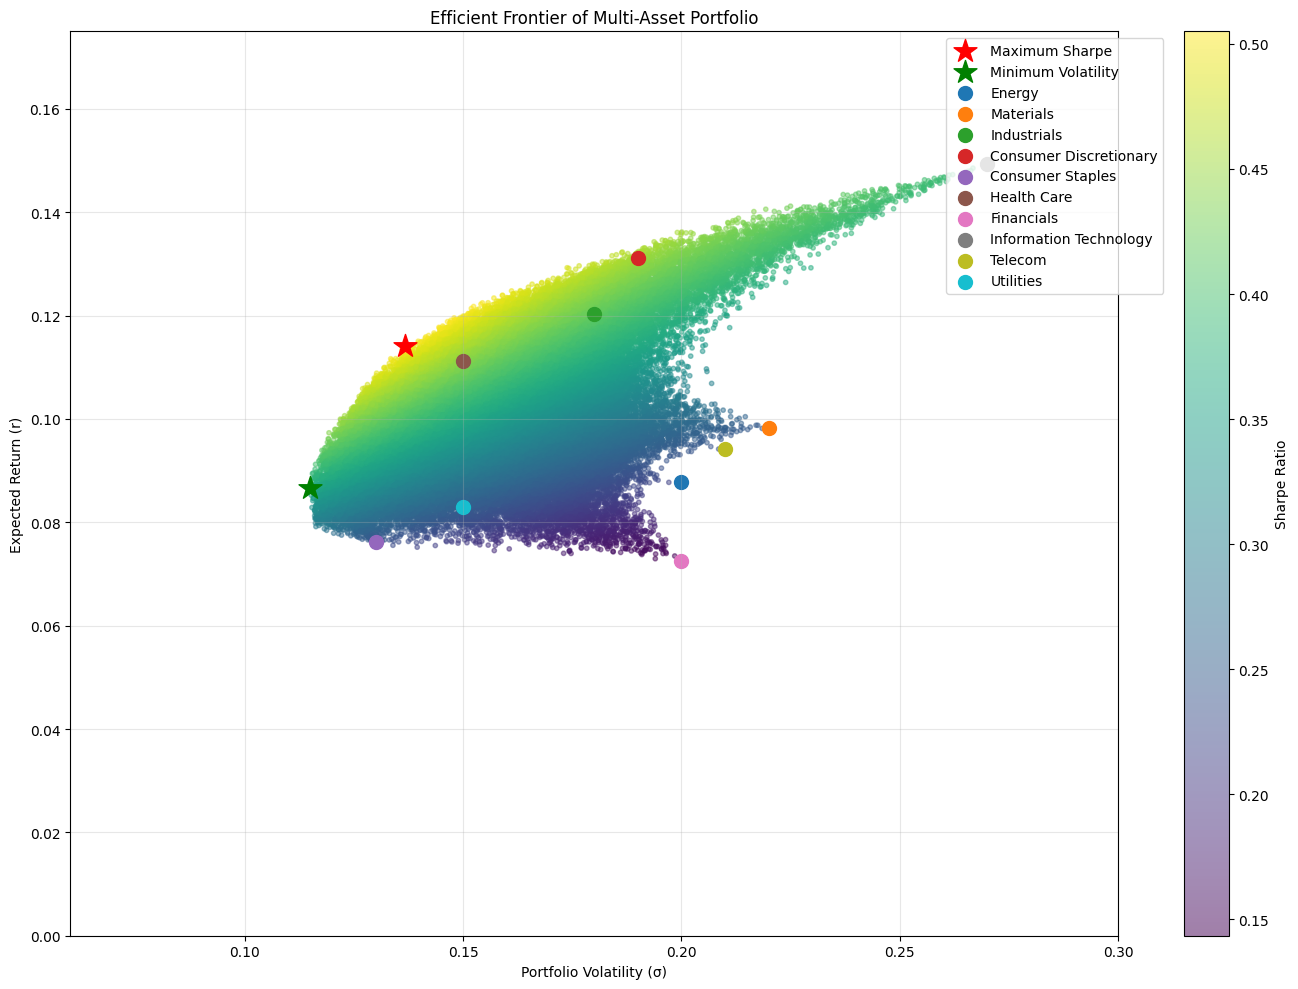

--------------------------------------------------
Maximum Sharpe Ratio Portfolio Allocation

Energy: 0.01%
Materials: 0.04%
Industrials: 0.06%
Consumer Discretionary: 29.37%
Consumer Staples: 0.14%
Health Care: 48.77%
Financials: 0.00%
Information Technology: 4.76%
Telecom: 0.00%
Utilities: 16.84%
Expected Return: 11.41%
Expected Volatility: 13.68%
Sharpe Ratio: 0.51

--------------------------------------------------
Minimum Volatility Portfolio Allocation

Energy: 4.56%
Materials: 0.45%
Industrials: 0.01%
Consumer Discretionary: 1.23%
Consumer Staples: 38.20%
Health Care: 13.46%
Financials: 0.10%
Information Technology: 1.14%
Telecom: 7.15%
Utilities: 33.70%
Expected Return: 8.66%
Expected Volatility: 11.50%
Sharpe Ratio: 0.36


In [4]:
opt = MultiAssetOptimisation(sector_returns, sector_volatilities, sector_corr, sectors, weighting_style='dirichlet')
opt.plot_efficient_frontier()